##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

### Import Libraries

In [2]:
import os
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import keras
import keras_hub

##### Load ImageNet Class Names

In [3]:
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

labels = requests.get(labels_url).text.strip().split("\n")

print("Number of classes:", len(labels))

Number of classes: 1000


#### Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)

In [4]:
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

#### Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)

In [5]:
model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet"
)

### Load the images

In [25]:
image_urls = {
    "labrador.jpg": "https://images.unsplash.com/photo-1524401033441-e87cab019093",
    "pug.jpg": "https://images.unsplash.com/photo-1591768575198-88dac53fbd0a",
    "elephant.jpg": "https://images.unsplash.com/photo-1611262084470-0e8686d7be78",
    "koala.jpg": "https://images.unsplash.com/photo-1649135527382-0d9e61377fa1",
    "snail.jpg": "https://images.unsplash.com/photo-1567161291513-d8d58620c5ca?q=80&w=1146&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
}

In [26]:
os.makedirs("images", exist_ok=True)

for name, url in image_urls.items():
    path = os.path.join("images", name)
    
    if not os.path.exists(path):
        img_data = requests.get(url).content
        with open(path, "wb") as f:
            f.write(img_data)

print("Images downloaded")

Images downloaded


In [27]:
images = []
filenames = []
for name in image_urls.keys():
    path = os.path.join("images", name)
    img = Image.open(path).convert("RGB").resize((224,224))
    images.append(np.array(img))
    filenames.append(name)

images = np.stack(images)

### Preprocess Images

In [28]:
images_preprocessed = preprocessor(images)

### Predict Classes

In [29]:
preds = model(images_preprocessed)
pred_labels = tf.argmax(preds, axis=-1).numpy()

### Show Predictions

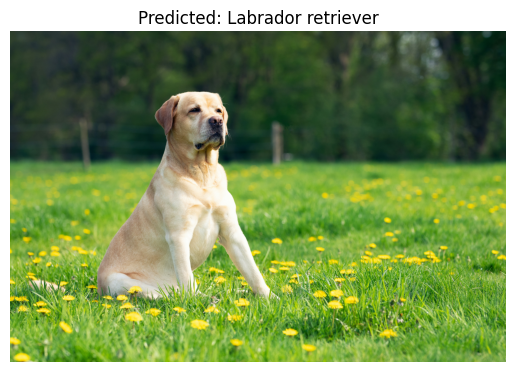

Image: labrador.jpg
Predicted: Labrador retriever



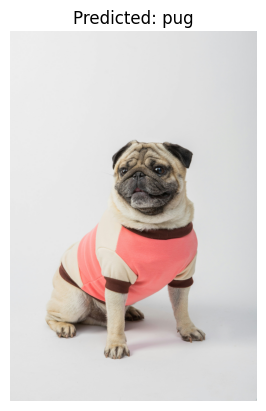

Image: pug.jpg
Predicted: pug



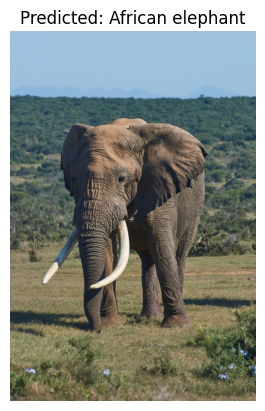

Image: elephant.jpg
Predicted: African elephant



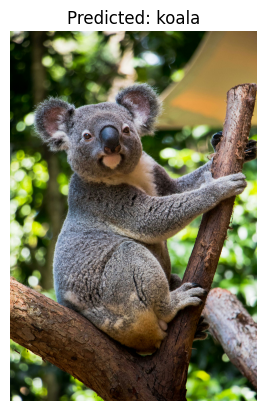

Image: koala.jpg
Predicted: koala



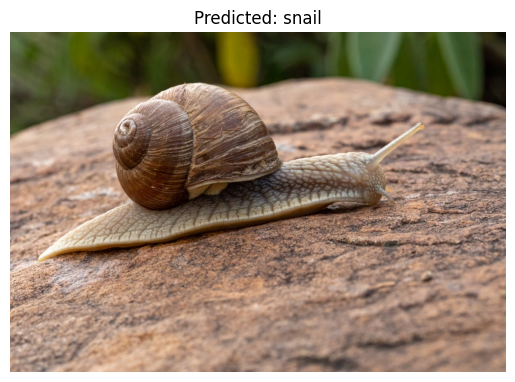

Image: snail.jpg
Predicted: snail



In [30]:
imagenet_labels = requests.get(
    "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
).text.splitlines()

for f, label_idx in zip(filenames, pred_labels):
    img_path = os.path.join("images", f)
    img = Image.open(img_path)
    
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {imagenet_labels[label_idx]}")
    plt.show()
    
    print(f"Image: {f}\nPredicted: {imagenet_labels[label_idx]}\n")

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label    | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | ------------------ | ------------------------------ | ----------------- |
| labrador.jpg | Labrador retriever | Labrador retriever             | Yes               |
| pug.jpg      | pug                | pug                            | Yes               |
| elephant.jpg | African elephant   | African elephant               | Yes               |
| koala.jpg    | koala              | koala                          | Yes               |
| snail.jpg    | snail              | snail                          | Yes                |

